# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score, RandomizedSearchCV, GridSearchCV, RepeatedKFold
from sklearn.metrics import make_scorer, mean_absolute_error
from sklearn.base import clone
import optuna.visualization as vis
import optuna
from optuna.samplers import TPESampler
import time
from tqdm import tqdm

random_state = 42

c:\Users\cbuser\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [3]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [4]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

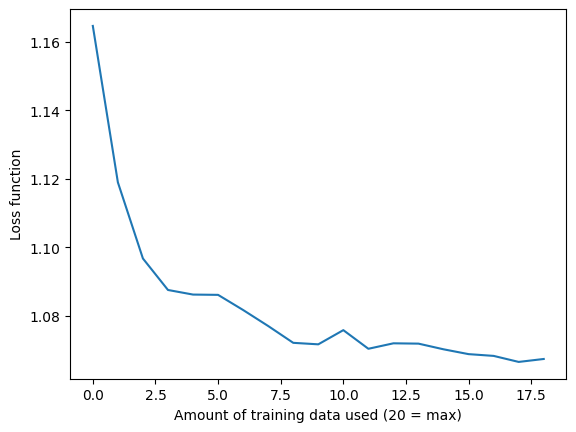

In [5]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [6]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

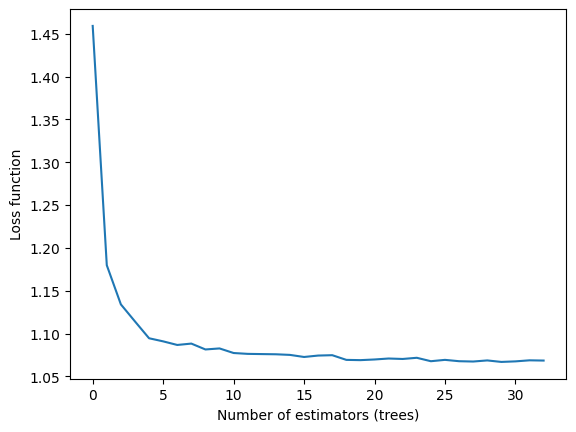

In [7]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

### Answer
#### If I had to cut one of the two plots, I would cut the second one - the plot showing loss as a function of the amount of training data used. While it confirms the expected pattern that more data improves performance, it offers limited practical value beyond that obvious takeaway. On the other hand, the plot showing loss as a function of the number of estimators (trees) is more interesting and useful. It shows us how the model's verall complexity affects performance and helps identify where additional trees stop yielding significant improvements - information that's directly actionable during model tuning. The number of estimators is a parameter we can control and optimize, whereas training data size is often fixed or dictated by external factors. From a model optimization standpoint, the first plot provides more insight and utility, making it the one to keep.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

In [12]:
# imports
import kagglehub
import os
import gc
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Download the datasets
olist_dataset_link = "olistbr/brazilian-ecommerce"
vgrecs_dataset_link = "antonkozyriev/game-recommendations-on-steam"
vgsales_dataset_link = "ashaheedq/video-games-sales-2019"

olist_path = kagglehub.dataset_download(olist_dataset_link)
vgrec_path = kagglehub.dataset_download(vgrecs_dataset_link)
vgsales_path = kagglehub.dataset_download(vgsales_dataset_link)

In [18]:
# helper functions (forward feature selection, backward selection, sweep parameter)

# Backwards and Forwards feature selection functions
def backward_feature_selection(X, y, model, 
                               scoring='neg_mean_squared_error', 
                               cv = 5, 
                               tol=None,               # None = no delta cutoff
                                                       # use 0.0 for "no further improvements"
                                                       # and 1e-4 for "point of diminishing returns"                                      
                               max_features=None,      # If None, remove features until only 1 remains
                                                       # Otherwise, stop when this many features remain
                               n_jobs=-1,
                               verbose=False
                              ):
    
    # Helper function to compute CV score using LinearRegression
    def cv_score(features):
        return -cross_val_score(model, X[features], y, 
                                scoring=scoring, cv=cv, 
                                n_jobs=n_jobs          ).mean()
    
    # Start with all features (using a list for easier manipulation)
    features_remaining = list(X.columns)
    
    # Compute initial CV score with the full feature set
    initial_score = cv_score(features_remaining)
    
    # Initialize tracking variables
    best_score        = initial_score                # Best (lowest) CV score observed so far
    best_feature_set  = features_remaining.copy()    # Feature set corresponding to best_score
    selected_features = ['NONE']                     # List to record the order in which features are removed
    best_scores       = [initial_score]              # List to record the CV score after each removal (starting with full set)
    
    if verbose:
        print("Start with full set of features:")
        print(f'{features_remaining}  CV score (MSE): {np.around(initial_score, 4)}\n')
    
    # Determine the target number of features to keep:
    # For backward elimination, if max_features is None, we remove until 1 feature remains.
    target_feature_count = 1 if max_features is None else max_features
    
    prev_score = initial_score
    round_num = 1
    # Continue removing features until we reach the target count
    while len(features_remaining) > target_feature_count:
        if verbose:
            print(f'Round {round_num}:')
            
        # Initialize variables to track the best removal in this round
        lowest_score = float('inf')
        feature_to_remove = None
        best_new_features = None
        
        # Try removing each feature one at a time
        for feature in features_remaining:
            new_feature_set = features_remaining.copy()
            new_feature_set.remove(feature)
            new_score = cv_score(new_feature_set)
            if verbose:
                print('Trying removal of:',feature, np.around(new_score, 4))
            if new_score < lowest_score:
                lowest_score = new_score
                feature_to_remove = feature
                best_new_features = new_feature_set
        
        # Check if improvement is significant enough (if tol is set)
        if tol is not None and (prev_score - lowest_score) < tol:
            if verbose:
                print("\nStopping early due to minimal improvement.")
            break
        
        # Update the best score and feature set if current removal improves performance
        if lowest_score < best_score:
            best_score = lowest_score
            best_feature_set = best_new_features.copy()
        
        # Update trackers for this round
        prev_score = lowest_score
        features_remaining = best_new_features
        selected_features.append(feature_to_remove)
        best_scores.append(lowest_score)
        
        if verbose:
            print(f'\nRemoving {feature_to_remove}:  CV score (MSE) {np.around(lowest_score, 4)}\n')
        round_num += 1

    final_model = clone(model)
    final_model.fit(X[best_feature_set], y)
    best_y_pred = final_model.predict(X[best_feature_set])

    return (
        selected_features,      # Order in which features were removed
        best_scores,            # CV scores after each removal step
        best_feature_set,       # Feature set that achieved the best CV score
        best_score,              # Best (lowest) CV score
        best_y_pred
    )

def forward_feature_selection(X, y, model, 
                              scoring='neg_mean_squared_error', 
                              cv = 5, 
                              tol=None,               # None = no delta cutoff
                                                      # use 0.0 for "no further improvements"
                                                      # and 1e-4 for "point of diminishing returns"                                      
                              max_features=None,      # None = use all features
                              n_jobs=-1,
                              verbose=False
                             ):
    selected_features = []                            # List to store the order of features selected
    remaining_features = list(X.columns)              # Features not yet selected
    best_scores = []                                  # List to store the CV score after each feature addition
    previous_score = float('inf')                     # Initialize previous score for improvement comparison

    # Track the best subset of features and its corresponding score
    
    best_feature_set = None                           # Best combination of features found so far
    best_score = float('inf')                         # Best CV score observed so far
    
    while remaining_features:
        scores = {}                                   # Dictionary to hold CV scores for each candidate feature
        for feature in remaining_features:
            current_features = selected_features + [feature]
            
            # Compute the CV score for the current set of features (negated MSE, so lower is better)
            cv_score = -cross_val_score(model, X[current_features], y, 
                                        scoring=scoring, cv=cv, n_jobs=n_jobs
                                       ).mean()
            scores[feature] = cv_score

        # Select the feature that minimizes the CV score
        best_feature = min(scores, key=scores.get)
        current_score = scores[best_feature]
            
        # Check if the improvement is significant based on the tolerance (tol)
        if tol is not None and previous_score - current_score < tol:
            if verbose:
                print("Stopping early due to minimal improvement.")
            break

        # Add the best feature to the selected list and update score trackers
        selected_features.append(best_feature)
        best_scores.append(current_score)
        remaining_features.remove(best_feature)
        previous_score = current_score

        if verbose:
            print(f"\nFeatures: {selected_features[-3:]}, CV Score (MSE): {current_score:.4f}")
        
        # Update the best subset if the current score is better than the best so far
        if current_score < best_score:
            best_score = current_score
            best_feature_set = selected_features.copy()
        
        # Check if the maximum number of features has been reached
        if max_features is not None and len(selected_features) >= max_features:
            break

####################Adding refitted model to output the best y prediction so the the transformed MAE can be calculated outside of the function 
    final_model = clone(model)
    final_model.fit(X[best_feature_set], y)
    best_y_pred = final_model.predict(X[best_feature_set])

    return (
        selected_features,      # List of features in the order they were selected (this will be ALL features if max_features == None
        best_scores,            # List of cross-validation scores corresponding to each addition in the previous list
        best_feature_set,       # The subset of features that achieved the best CV score.
        best_score,             # The best CV score
        best_y_pred
    )

def run_model(model, 
              X_train, y_train, 
              n_repeats=5, 
              n_jobs=-1, 
              **model_params
             ):

    # Instantiate the model if a class is provided
    if isinstance(model, type):
        model = model(**model_params)
    else:                                    
        model.set_params(**model_params)    

    # Use negative MAE for cross-validation (since sklearn minimizes loss)
    neg_mae_scores = cross_val_score(
        model, 
        X_train, y_train,
        scoring='neg_mean_absolute_error',
        cv=RepeatedKFold(n_splits=5, n_repeats=n_repeats, random_state=random_state), 
        n_jobs=n_jobs
    )
    
    mean_cv_mae = -np.mean(neg_mae_scores)
    std_cv_mae  =  np.std(neg_mae_scores)
    
    # Fit the model on the full training set
    model.fit(X_train, y_train)
    
    # Compute training MAE
    train_preds = model.predict(X_train)
    train_mae   = mean_absolute_error(y_train, train_preds)
    
    return mean_cv_mae, std_cv_mae, train_mae



def sweep_parameter(model,
                    Parameters,
                    param,
                    parameter_list,
                    X_train          = X_train,              # Defined above
                    y_train          = y_train,
                    verbose          = True,
                    show_mae         = True,
                    show_std         = True,
                    n_iter_no_change = None,
                    delta            = 0.001,
                    n_jobs           = -1,
                    n_repeats        = 5
                   ):
    

    start = time.time()
    Parameters = Parameters.copy()  # Avoid modifying the original dictionary
    
    cv_maes, std_cvs, train_maes = [], [], []
    no_improve_count = 0
    best_mae = float('inf')
    
    # Run over each value in parameter_list
    for p in tqdm(parameter_list, desc=f"Sweeping {param}"):
        Parameters[param] = p
        P_temp = Parameters.copy()
        P_temp.pop('MAE_found', None)  # Just in case
        P_temp.pop('MAE_Stdev', None) # Just in case
        
        cv_mae, std_cv, train_mae = run_model(
            model=model,
            X_train=X_train, y_train=y_train,
            n_repeats=n_repeats,
            n_jobs=n_jobs,
            **P_temp
        )
        cv_maes.append(cv_mae)
        std_cvs.append(std_cv)
        train_maes.append(train_mae)
        
        if cv_mae < best_mae - delta:
            best_mae = cv_mae
            no_improve_count = 0
        else:
            no_improve_count += 1
        
        if n_iter_no_change is not None and no_improve_count >= n_iter_no_change:
            print(f"Early stopping: No improvement after {n_iter_no_change} iterations.")
            break

    # Identify best parameter
    min_cv_mae = min(cv_maes)
    min_cv_stdev = min(std_cvs)
    min_index = cv_maes.index(min_cv_mae)
    best_param = parameter_list[min_index]
    Parameters[param] = best_param
    Parameters['MAE_found'] = min_cv_mae
    Parameters['MAE_Stdev'] = min_cv_stdev

    # ---------- Plotting section ----------
    if verbose:
        partial_param_list = parameter_list[:len(cv_maes)]

        is_boolean = all(isinstance(val, bool) for val in partial_param_list)
        if is_boolean:
            x_vals = list(range(len(partial_param_list)))
            x_labels = [str(val) for val in partial_param_list]
        else:
            x_vals = partial_param_list
            x_labels = partial_param_list

        error_name = 'MAE'

        # Create appropriate number of subplots
        if show_std:
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
        else:
            fig, ax1 = plt.subplots(1, 1, figsize=(8, 4))

        ax1.set_title(f"{error_name} vs {param}")
        # if show_mae:
        #     ax1.yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

        ax1.plot(x_vals,
                 cv_maes,
                 marker='.', label="CV MAE", color='blue')
        ax1.plot(x_vals,
                 train_maes,
                 marker='.', label="Train MAE", color='green')
        ax1.scatter([x_vals[min_index]],
                    [min_cv_mae],
                    marker='x', label="Best CV MAE", color='red')

        ax1.set_ylabel(error_name)
        ax1.legend()
        ax1.grid()

        # Optional Std Dev Plot
        if show_std:
            ax2.set_title(f"CV Standard Deviation vs {param}")
            ax2.plot(x_vals, std_cvs, marker='.', label="CV MAE Std", color='blue')
            ax2.set_xlabel(param)
            ax2.set_ylabel("Standard Deviation")
            ax2.legend()
            ax2.grid(alpha=0.5)

            if is_boolean:
                ax2.set_xticks(x_vals)
                ax2.set_xticklabels(x_labels)
        else:
            ax1.set_xlabel(param)
            if is_boolean:
                ax1.set_xticks(x_vals)
                ax1.set_xticklabels(x_labels)

        plt.tight_layout()
        plt.show()

        end = time.time()
        print("Execution Time:", time.strftime("%H:%M:%S", time.gmtime(end - start)))

    return Parameters


# Video Game Sales Dataset

In [16]:
# Load Video Game Sales data
vgsales_df_raw = pd.read_csv(os.path.join(vgsales_path, "vgsales-12-4-2019-short.csv"))
vgsales_df_cleaned = vgsales_df_raw.dropna(subset=["Year"]).copy()
vgsales_df_cleaned["ESRB_Rating"] = vgsales_df_cleaned["ESRB_Rating"].fillna("RP")
vgsales_df_cleaned["Developer"] = vgsales_df_cleaned["Developer"].fillna("Unknown")
sales_cols = ["Global_Sales", "NA_Sales", "PAL_Sales", "JP_Sales", "Other_Sales"]
vgsales_df_cleaned[sales_cols] = vgsales_df_cleaned[sales_cols].fillna(0)
vgsales_df_cleaned = vgsales_df_cleaned[vgsales_df_cleaned["Year"] <= 2025]
regional_sum = vgsales_df_cleaned[["NA_Sales", "PAL_Sales", "JP_Sales", "Other_Sales"]].sum(axis=1)
vgsales_df_cleaned = vgsales_df_cleaned[vgsales_df_cleaned["Global_Sales"] >= regional_sum]
vgsales_df_cleaned = vgsales_df_cleaned.drop(columns=["Total_Shipped"])

# Impute null score values with median
# vgsales_df_cleaned['Critic_Score'] = vgsales_df_cleaned['Critic_Score'].fillna(vgsales_df_cleaned['Critic_Score'].median())
# vgsales_df_cleaned['User_Score'] = vgsales_df_cleaned['User_Score'].fillna(vgsales_df_cleaned['User_Score'].median())


# Encode Video Game Sales
vgsales_df_cleaned_encoded = vgsales_df_cleaned.copy()
# One-Hot Encoding: Genre and ESRB_Rating
vgsales_df_cleaned_encoded = pd.get_dummies(vgsales_df_cleaned_encoded, columns=["Genre", "ESRB_Rating"], prefix=["Genre", "ESRB"])
# Platform Encoding: Top 10 + “Other”, then one-hot encoding it
top_platforms = vgsales_df_cleaned_encoded["Platform"].value_counts().nlargest(10).index
vgsales_df_cleaned_encoded["Platform"] = vgsales_df_cleaned_encoded["Platform"].where(vgsales_df_cleaned_encoded["Platform"].isin(top_platforms), other="Other")
vgsales_df_cleaned_encoded = pd.get_dummies(vgsales_df_cleaned_encoded, columns=["Platform"], prefix="Platform")
# Frequency Encoding: Publisher and Developer
for col in ["Publisher", "Developer"]:
    freq_map = vgsales_df_cleaned_encoded[col].value_counts(normalize=True)
    vgsales_df_cleaned_encoded[col + "_freq"] = vgsales_df_cleaned_encoded[col].map(freq_map)
vgsales_df_cleaned_encoded = vgsales_df_cleaned_encoded.drop(columns=["Publisher", "Developer"])

In [17]:
# prepare features and target

# drop unhelpful columns
leakage_cols = ["Name", "Rank", "Global_Sales", "NA_Sales", "PAL_Sales", "JP_Sales", "Other_Sales", "User_Score", "Critic_Score"]
X = vgsales_df_cleaned_encoded.drop(columns=leakage_cols)
y = vgsales_df_cleaned_encoded["Global_Sales"]
# log transformed
y_log = np.log1p(y)

# confirm shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# log train/test split
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)


X shape: (51231, 42)
y shape: (51231,)


In [20]:
# baseline model performance
# instantiate models
lr = LinearRegression()
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# fit and predict
lr.fit(X_train, y_train_log)
rf.fit(X_train, y_train_log)

# Predict and inverse-transform
lr_preds = np.expm1(lr.predict(X_test))
rf_preds = np.expm1(rf.predict(X_test))
y_test = np.expm1(y_test_log)

# evaluate
vgsales_linear_baseline_mae = mean_absolute_error(y_test, lr_preds)
vgsales_rf_baseline_mae = mean_absolute_error(y_test, rf_preds)
print(f"Linear Regression Baseline MAE: {vgsales_linear_baseline_mae}")
print(f"Random Forest Baseline MAE: {vgsales_rf_baseline_mae}")


Linear Regression Baseline MAE: 0.12648944295153242
Random Forest Baseline MAE: 0.0961798040576679


In [21]:
# 5 fold cross validation on log target
vgsales_baseline_lr_cv = -cross_val_score(lr, X_train, y_train_log, scoring='neg_mean_absolute_error', cv=5).mean()
vgsales_baseline_rf_cv = -cross_val_score(rf, X_train, y_train_log, scoring='neg_mean_absolute_error', cv=5, n_jobs=-1).mean()

print("CV MAE - Linear Regression:", vgsales_baseline_lr_cv)
print("CV MAE - Random Forest:", vgsales_baseline_rf_cv)


CV MAE - Linear Regression: 0.08921930348394998
CV MAE - Random Forest: 0.06023239795901399


In [22]:
# feature selections
# forward felection
fwd_removed_order, fwd_cv_scores, fwd_feature_set, fwd_cv_mae, _ = forward_feature_selection(
    X_train, y_train_log,
    model=LinearRegression(),
    tol=1e-4, cv=5, n_jobs=-1,
    verbose=False,
    scoring='neg_mean_absolute_error'
)

# backward selection
bwd_removed_order, bwd_cv_scores, bwd_feature_set, bwd_cv_mae, _ = backward_feature_selection(
    X_train, y_train_log,
    model=LinearRegression(),
    tol=1e-4, cv=5, n_jobs=-1,
    verbose=False,
    scoring='neg_mean_absolute_error'
)

# output
print("Forward Selection Results:")
print(f"Best MAE: {fwd_cv_mae:.5f}")
print(f"Number of Selected Features: {len(fwd_feature_set)}")
print("Selected Features:", fwd_feature_set)

print("\nBackward Selection Results:")
print(f"Best MAE: {bwd_cv_mae:.5f}")
print(f"Number of Selected Features: {len(bwd_feature_set)}")
print("Selected Features:", bwd_feature_set)


Forward Selection Results:
Best MAE: 0.08051
Number of Selected Features: 7
Selected Features: ['ESRB_RP', 'Platform_PS3', 'Platform_PS2', 'Platform_PSP', 'Platform_DS', 'Genre_Sports', 'ESRB_E']

Backward Selection Results:
Best MAE: 0.08922
Number of Selected Features: 42
Selected Features: ['Year', 'Genre_Action', 'Genre_Action-Adventure', 'Genre_Adventure', 'Genre_Board Game', 'Genre_Education', 'Genre_Fighting', 'Genre_MMO', 'Genre_Misc', 'Genre_Music', 'Genre_Party', 'Genre_Platform', 'Genre_Puzzle', 'Genre_Racing', 'Genre_Role-Playing', 'Genre_Sandbox', 'Genre_Shooter', 'Genre_Simulation', 'Genre_Sports', 'Genre_Strategy', 'Genre_Visual Novel', 'ESRB_AO', 'ESRB_E', 'ESRB_E10', 'ESRB_EC', 'ESRB_KA', 'ESRB_M', 'ESRB_RP', 'ESRB_T', 'Platform_DS', 'Platform_GB', 'Platform_GBA', 'Platform_Other', 'Platform_PC', 'Platform_PS', 'Platform_PS2', 'Platform_PS3', 'Platform_PSN', 'Platform_PSP', 'Platform_XBL', 'Publisher_freq', 'Developer_freq']


In [23]:
# randomforest base parameters
rf_sweep_params = {
    "n_estimators": 100,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 1
}

Sweeping max_depth: 100%|██████████| 7/7 [01:35<00:00, 13.60s/it]


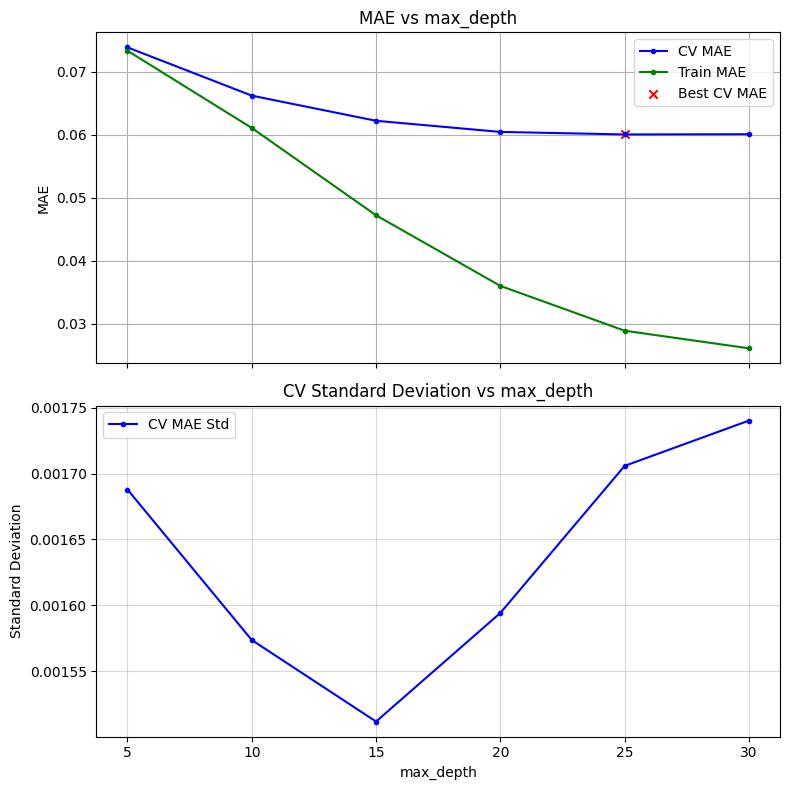

Execution Time: 00:01:35


Sweeping min_samples_split: 100%|██████████| 5/5 [01:15<00:00, 15.16s/it]


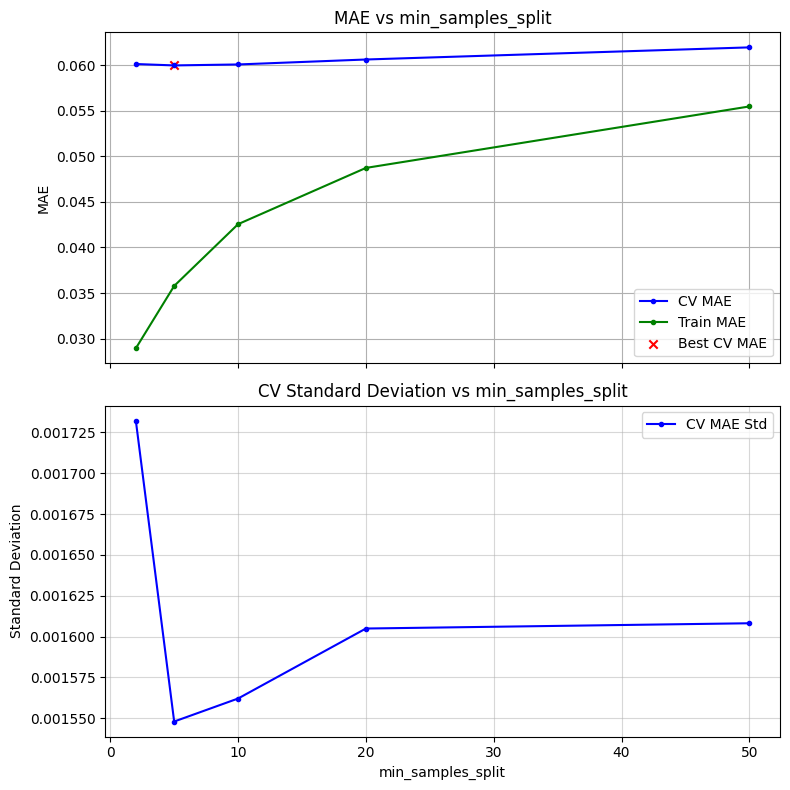

Execution Time: 00:01:15


Sweeping n_estimators: 100%|██████████| 4/4 [01:40<00:00, 25.23s/it]


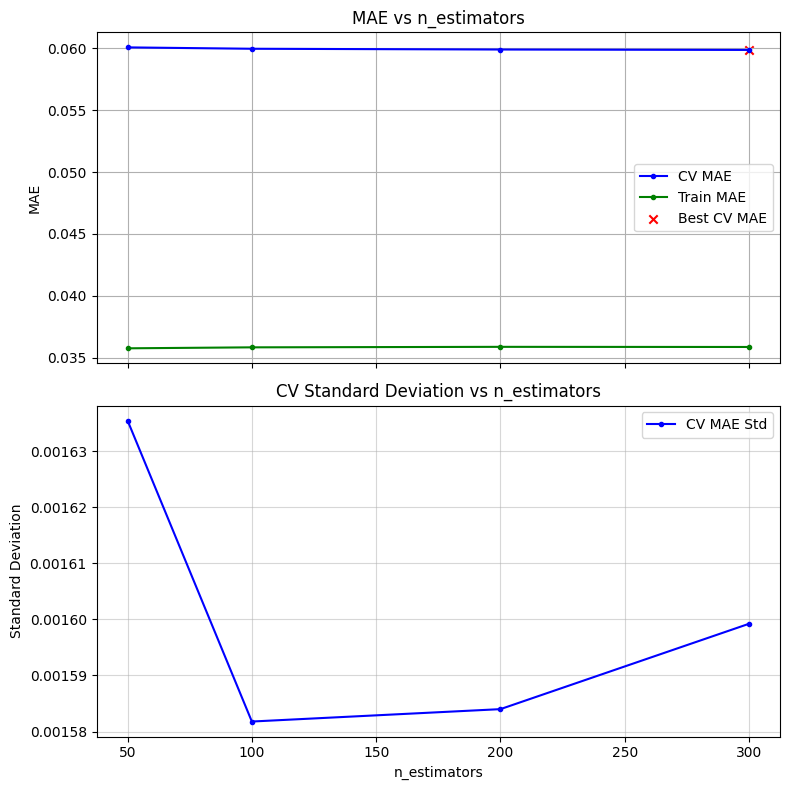

Execution Time: 00:01:41
Final Random Forest swept parameters: {'n_estimators': 300, 'max_depth': 25, 'min_samples_split': 5, 'min_samples_leaf': 1, 'MAE_found': np.float64(0.05987603154200939), 'MAE_Stdev': np.float64(0.0015817852779127287)}


In [24]:
# sweep parameters

# sweep max_depth
rf_sweep_params = sweep_parameter(
    model=RandomForestRegressor,
    Parameters=rf_sweep_params,
    param="max_depth",
    parameter_list=[5, 10, 15, 20, 25, 30, None],
    X_train=X_train,
    y_train=y_train_log,
    verbose=True
)

# sweep min_samples_split
rf_sweep_params = sweep_parameter(
    model=RandomForestRegressor,
    Parameters=rf_sweep_params,
    param="min_samples_split",
    parameter_list=[2, 5, 10, 20, 50],
    X_train=X_train,
    y_train=y_train_log,
    verbose=True
)

# sweep n_estimators
rf_sweep_params = sweep_parameter(
    model=RandomForestRegressor,
    Parameters=rf_sweep_params,
    param="n_estimators",
    parameter_list=[50, 100, 200, 300],
    X_train=X_train,
    y_train=y_train_log,
    verbose=True
)

print("Final Random Forest swept parameters:", rf_sweep_params)


In [25]:
# objective function for Optuna
def rf_vgsales_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 150, 250),
        "max_depth": trial.suggest_int("max_depth", 20, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        "random_state": 42,
        "n_jobs": -1
    }

    model = RandomForestRegressor(**params)
    scores = cross_val_score(
        model,
        X_train,
        y_train_log,
        scoring="neg_mean_absolute_error",
        cv=5,
        n_jobs=-1
    )
    return scores.mean()

rf_vgsales_study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=42)
)

rf_vgsales_study.optimize(rf_vgsales_objective, n_trials=50)

# Print results
print("Best parameters found:")
print(rf_vgsales_study.best_trial.params)
print("Best CV MAE:", -rf_vgsales_study.best_value)

[I 2025-08-03 11:37:52,600] A new study created in memory with name: no-name-51938eb5-3f59-4291-9a37-c98f6a9abf7a
[I 2025-08-03 11:37:55,047] Trial 0 finished with value: -0.059083813053993114 and parameters: {'n_estimators': 187, 'max_depth': 30, 'min_samples_split': 8, 'min_samples_leaf': 3}. Best is trial 0 with value: -0.059083813053993114.
[I 2025-08-03 11:37:57,033] Trial 1 finished with value: -0.05989011843076321 and parameters: {'n_estimators': 165, 'max_depth': 21, 'min_samples_split': 2, 'min_samples_leaf': 5}. Best is trial 0 with value: -0.059083813053993114.
[I 2025-08-03 11:37:59,571] Trial 2 finished with value: -0.05948081416821473 and parameters: {'n_estimators': 210, 'max_depth': 27, 'min_samples_split': 2, 'min_samples_leaf': 5}. Best is trial 0 with value: -0.059083813053993114.
[I 2025-08-03 11:38:02,642] Trial 3 finished with value: -0.06021861154532478 and parameters: {'n_estimators': 234, 'max_depth': 22, 'min_samples_split': 3, 'min_samples_leaf': 1}. Best is 

Best parameters found:
{'n_estimators': 218, 'max_depth': 29, 'min_samples_split': 5, 'min_samples_leaf': 3}
Best CV MAE: 0.058994084390140464


In [26]:
# final model using best params
best_rf_vgsales = RandomForestRegressor(
    **rf_vgsales_study.best_trial.params,
    random_state=42,
    n_jobs=-1
)
best_rf_vgsales.fit(X_train, y_train_log)

# evaluate on test set
final_preds_log = best_rf_vgsales.predict(X_test)
final_preds = np.expm1(final_preds_log)
final_mae = mean_absolute_error(np.expm1(y_test_log), final_preds)

print("Final Test MAE:", final_mae)

Final Test MAE: 0.0934188709090647


# Video Game Recommendations Dataset

In [35]:
# Load Video Game Recommendations data
vgrecs_recs_df_raw = pd.read_csv(os.path.join(vgrec_path, "recommendations.csv"))
vgrecs_users_df_raw = pd.read_csv(os.path.join(vgrec_path, "users.csv"))
vgrecs_games_df_raw = pd.read_csv(os.path.join(vgrec_path, "games.csv"))
vgrecs_game_metadata_path = os.path.join(vgrec_path, "games_metadata.json")
meta_df = pd.read_json(vgrecs_game_metadata_path, lines=True)


vgrecs_merged_df = vgrecs_recs_df_raw.merge(vgrecs_users_df_raw, on="user_id", how="left")
vgrecs_merged_df = vgrecs_merged_df.merge(vgrecs_games_df_raw, on="app_id", how="left")
vgrecs_merged_df["date_release"] = pd.to_datetime(vgrecs_merged_df["date_release"], errors="coerce")

# keep only app_id + first tag = genre
tag_lookup = (
    meta_df
      .assign(genre=lambda d: d["tags"].str[0])
      .loc[:, ["app_id", "genre"]]
      .drop_duplicates("app_id")
)

vgrecs_merged_df = vgrecs_merged_df.merge(tag_lookup, on="app_id", how="left")
vgrecs_merged_df["genre"] = vgrecs_merged_df["genre"].fillna("No Category")

print(f"Raw: {vgrecs_merged_df.shape}")
# cut data in quarter because it is too large for my kernel
vgrecs_merged_df = vgrecs_merged_df.sample(frac=0.10, random_state=42)
# remove anything with price over 175, it makes no sense to unneccesarily distort games
vgrecs_merged_df = vgrecs_merged_df[vgrecs_merged_df["price_final"] <= 175]

print(f"Cleaned: {vgrecs_merged_df.shape}")

# clean up the unused dataframes
del vgrecs_recs_df_raw
del vgrecs_users_df_raw
del vgrecs_games_df_raw
del meta_df
gc.collect()

# Encode Video Game Recommendations
vgrecs_merged_df_encoded = vgrecs_merged_df.copy()
rating_order = ['Overwhelmingly Negative', 'Very Negative', 'Mostly Negative', 'Negative', 'Mixed', 'Positive', 'Mostly Positive', 'Very Positive', 'Overwhelmingly Positive']
rating_map = {label: idx for idx, label in enumerate(rating_order)}
vgrecs_merged_df_encoded['rating_encoded'] = vgrecs_merged_df_encoded['rating'].map(rating_map)

Raw: (41154794, 23)
Cleaned: (4115463, 23)


In [36]:
# define X and y
X_vgrecs = vgrecs_merged_df_encoded.drop(columns=["rating", "rating_encoded", "title", "date"])
y_vgrecs = vgrecs_merged_df_encoded["rating_encoded"]

# drop non-numeric/high cardinality/ID columns
drop_cols = X_vgrecs.select_dtypes(include=["object", "datetime64[ns]"]).columns
X_vgrecs = X_vgrecs.drop(columns=drop_cols)

print("X_vgrecs shape:", X_vgrecs.shape)
print("y_vgrecs shape:", y_vgrecs.shape)

X_vgrecs_train, X_vgrecs_test, y_vgrecs_train, y_vgrecs_test = train_test_split(
    X_vgrecs, y_vgrecs, test_size=0.2, random_state=42
)

X_vgrecs shape: (4115463, 18)
y_vgrecs shape: (4115463,)


In [ ]:
# baseline model
rf_vgrecs_baseline = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_vgrecs_baseline.fit(X_vgrecs_train, y_vgrecs_train)

# predict and evaluate
vgrecs_preds_baseline = rf_vgrecs_baseline.predict(X_vgrecs_test)
vgrecs_baseline_mae = mean_absolute_error(y_vgrecs_test, vgrecs_preds_baseline)

print("Baseline vgrecs RF MAE:", vgrecs_baseline_mae)

In [ ]:
# cross validation
vgrecs_cv_mae = -cross_val_score(
    rf_vgrecs_baseline,
    X_vgrecs_train,
    y_vgrecs_train,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1
).mean()

print("Cross-validated MAE (vgrecs RF):", vgrecs_cv_mae)

In [ ]:
# running the optuna study (avoiding to sweep parameters because it's useless for this dataset)
def rf_vgrecs_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 300),
        "max_depth": trial.suggest_int("max_depth", 10, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        "random_state": 42,
        "n_jobs": -1
    }

    model = RandomForestRegressor(**params)
    scores = cross_val_score(
        model,
        X_vgrecs_train,
        y_vgrecs_train,
        scoring="neg_mean_absolute_error",
        cv=5,
        n_jobs=-1
    )
    return scores.mean()

# Create and run Optuna study
rf_vgrecs_study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=42)
)
rf_vgrecs_study.optimize(rf_vgrecs_objective, n_trials=50)

# Output results
print("Best parameters (vgrecs):", rf_vgrecs_study.best_trial.params)
print("Best CV MAE (vgrecs):", -rf_vgrecs_study.best_value)

# Olist Dataset

In [27]:
# Load Olist datasets
olist_products_df_raw = pd.read_csv(os.path.join(olist_path, "olist_products_dataset.csv"))
olist_translation_df_raw = pd.read_csv(os.path.join(olist_path, "product_category_name_translation.csv"))
olist_reviews_df_raw = pd.read_csv(os.path.join(olist_path, "olist_order_reviews_dataset.csv"))
olist_orders_df_raw = pd.read_csv(os.path.join(olist_path, "olist_orders_dataset.csv"))
olist_customers_df_raw = pd.read_csv(os.path.join(olist_path, "olist_customers_dataset.csv"))
olist_items_df_raw = pd.read_csv(os.path.join(olist_path, "olist_order_items_dataset.csv"))

# Merge Olist data
olist_products_df = olist_products_df_raw.merge(olist_translation_df_raw, how="left", on="product_category_name")
olist_order_lines_df = olist_items_df_raw.merge(olist_products_df, how="left", on="product_id")
olist_order_lines_df = olist_order_lines_df.merge(olist_orders_df_raw[["order_id", "customer_id", "order_purchase_timestamp"]], how="left", on="order_id")
olist_order_lines_df = olist_order_lines_df.merge(olist_customers_df_raw[["customer_id", "customer_unique_id", "customer_state"]], how="left", on="customer_id")
olist_merged_df = olist_order_lines_df.merge(olist_reviews_df_raw[["order_id", "review_score", "review_creation_date", "review_answer_timestamp"]], how="left", on="order_id")

# Clean Olist
olist_cleaned_df = olist_merged_df.drop_duplicates()
olist_cleaned_df = olist_cleaned_df.dropna(subset=["product_category_name", "product_category_name_english", "review_score", "product_weight_g"])
olist_cleaned_df["review_creation_date"] = pd.to_datetime(olist_cleaned_df["review_creation_date"])
olist_cleaned_df["order_purchase_timestamp"] = pd.to_datetime(olist_cleaned_df["order_purchase_timestamp"])
olist_cleaned_df["days_to_review"] = olist_cleaned_df["review_creation_date"] - olist_cleaned_df["order_purchase_timestamp"]
olist_cleaned_df = olist_cleaned_df[olist_cleaned_df["days_to_review"] >= pd.Timedelta(0)]
olist_cleaned_df = olist_cleaned_df.rename(columns={
    "product_name_lenght": "product_name_length",
    "product_description_lenght": "product_description_length"
})
olist_cleaned_df['order_purchase_timestamp'] = pd.to_datetime(olist_cleaned_df['order_purchase_timestamp'], errors='coerce')
olist_cleaned_df['shipping_limit_date'] = pd.to_datetime(olist_cleaned_df['shipping_limit_date'], errors='coerce')
olist_cleaned_df = olist_cleaned_df.drop(columns=["product_category_name"])

# Encode Olist
olist_cleaned_encoded_df = olist_cleaned_df.drop(columns=[
    "order_id", "customer_id", "product_id", "seller_id", "customer_unique_id",
    "review_creation_date", "shipping_limit_date", "review_answer_timestamp"
])
olist_cleaned_encoded_df = pd.get_dummies(olist_cleaned_encoded_df, columns=["product_category_name_english", "customer_state"])
olist_cleaned_encoded_df["days_to_review"] = olist_cleaned_encoded_df["days_to_review"].dt.total_seconds() / 86400


In [28]:
# define X and y
X_olist = olist_cleaned_encoded_df.drop(columns=["review_score", "order_purchase_timestamp"])
y_olist = olist_cleaned_encoded_df["review_score"]

# confirm shapes
print("X_olist shape:", X_olist.shape)
print("y_olist shape:", y_olist.shape)

# train test split
X_olist_train, X_olist_test, y_olist_train, y_olist_test = train_test_split(
X_olist, y_olist, test_size=0.2, random_state=42
)

X_olist shape: (110741, 109)
y_olist shape: (110741,)


In [29]:
# baseline model
rf_olist = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_olist.fit(X_olist_train, y_olist_train)

# predict and evaluate
olist_preds = rf_olist.predict(X_olist_test)
olist_mae = mean_absolute_error(y_olist_test, olist_preds)

print("Baseline Olist Random Forest MAE:", olist_mae)


Baseline Olist Random Forest MAE: 0.9773345491250814


In [30]:
# cross validation
cv_mae_olist = -cross_val_score(
    rf_olist,
    X_olist_train,
    y_olist_train,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1
).mean()

print("Cross-validated MAE (Olist RF):", cv_mae_olist)


Cross-validated MAE (Olist RF): 0.9876353358583924


In [31]:
# basline params to start
olist_rf_params = {
    "n_estimators": 100,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 1
}

Sweeping max_depth: 100%|██████████| 7/7 [19:49<00:00, 169.97s/it]


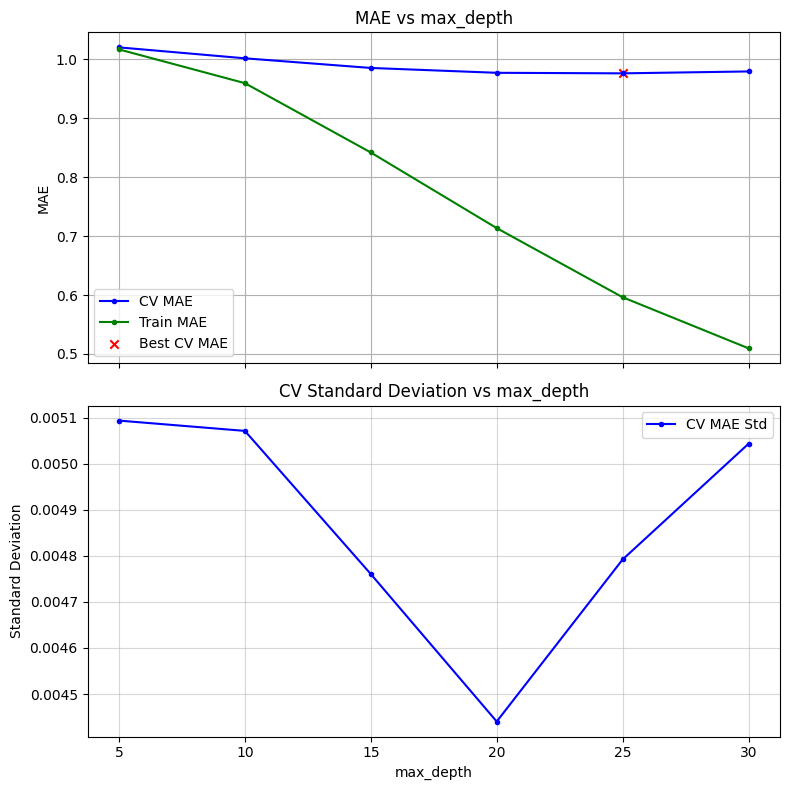

Execution Time: 00:19:49


Sweeping min_samples_split: 100%|██████████| 5/5 [17:21<00:00, 208.34s/it]


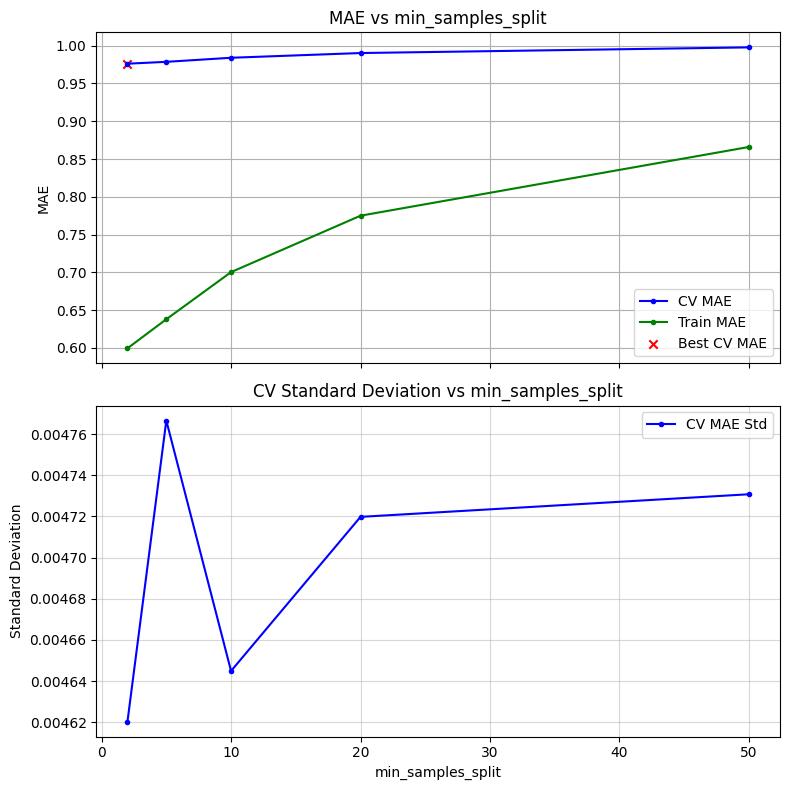

Execution Time: 00:17:21


Sweeping n_estimators: 100%|██████████| 4/4 [23:31<00:00, 352.79s/it]


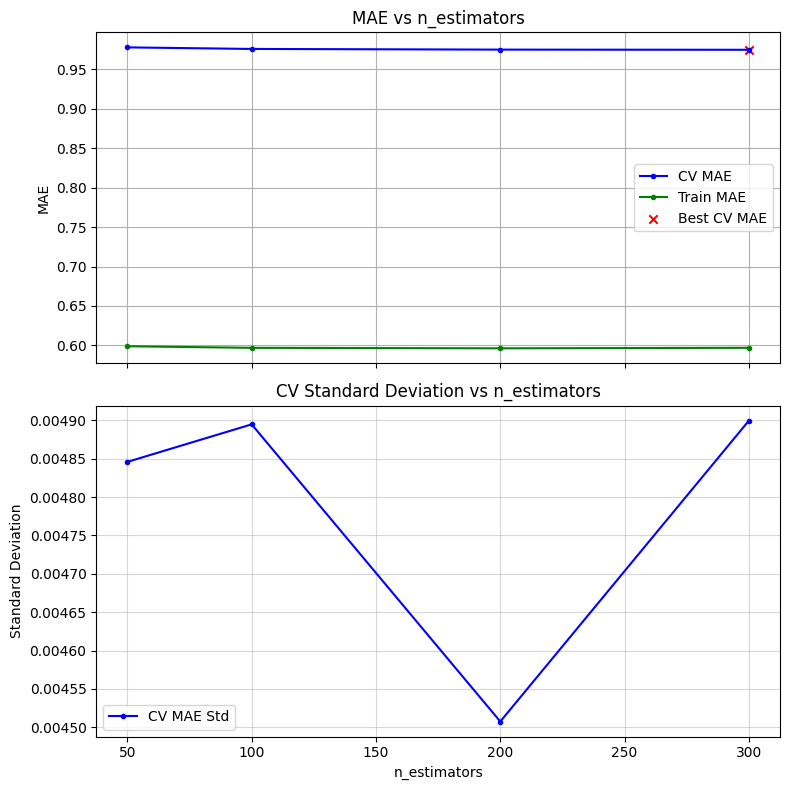

Execution Time: 00:23:31
Final swept RF parameters (Olist): {'n_estimators': 300, 'max_depth': 25, 'min_samples_split': 2, 'min_samples_leaf': 1, 'MAE_found': np.float64(0.9747920440285596), 'MAE_Stdev': np.float64(0.004507526272170235)}


In [32]:
# sweeping parameters
olist_rf_params = sweep_parameter(
    model=RandomForestRegressor,
    Parameters=olist_rf_params,
    param="max_depth",
    parameter_list=[5, 10, 15, 20, 25, 30, None],
    X_train=X_olist_train,
    y_train=y_olist_train,
    verbose=True
)

olist_rf_params = sweep_parameter(
    model=RandomForestRegressor,
    Parameters=olist_rf_params,
    param="min_samples_split",
    parameter_list=[2, 5, 10, 20, 50],
    X_train=X_olist_train,
    y_train=y_olist_train,
    verbose=True
)

olist_rf_params = sweep_parameter(
    model=RandomForestRegressor,
    Parameters=olist_rf_params,
    param="n_estimators",
    parameter_list=[50, 100, 200, 300],
    X_train=X_olist_train,
    y_train=y_olist_train,
    verbose=True
)

print("Final swept RF parameters (Olist):", olist_rf_params)


In [33]:
# Optuna study
def rf_olist_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "max_depth": trial.suggest_int("max_depth", 5, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "random_state": 42,
        "n_jobs": -1
    }

    model = RandomForestRegressor(**params)
    score = cross_val_score(
        model,
        X_olist_train,
        y_olist_train,
        scoring="neg_mean_absolute_error",
        cv=3,
        n_jobs=-1
    ).mean()

    return score

# create and run optuna study
rf_olist_study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=42)
)

# reduce number of trials for speed purposes
rf_olist_study.optimize(rf_olist_objective, n_trials=30)

# report results
print("Best parameters found:")
print(rf_olist_study.best_trial.params)
print("Best CV MAE:", -rf_olist_study.best_value)

[I 2025-08-03 12:45:36,034] A new study created in memory with name: no-name-f0ce4b85-62da-4006-a53a-150d33e9d375
[I 2025-08-03 12:45:48,533] Trial 0 finished with value: -0.9935626845265251 and parameters: {'n_estimators': 144, 'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 6}. Best is trial 0 with value: -0.9935626845265251.
[I 2025-08-03 12:45:52,208] Trial 1 finished with value: -1.0068722691056606 and parameters: {'n_estimators': 89, 'max_depth': 9, 'min_samples_split': 3, 'min_samples_leaf': 9}. Best is trial 0 with value: -0.9935626845265251.
[I 2025-08-03 12:46:06,979] Trial 2 finished with value: -0.9958664042892765 and parameters: {'n_estimators': 200, 'max_depth': 23, 'min_samples_split': 2, 'min_samples_leaf': 10}. Best is trial 0 with value: -0.9935626845265251.
[I 2025-08-03 12:46:19,760] Trial 3 finished with value: -1.001927285188483 and parameters: {'n_estimators': 258, 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 2}. Best is trial 0 with

Best parameters found:
{'n_estimators': 167, 'max_depth': 26, 'min_samples_split': 4, 'min_samples_leaf': 1}
Best CV MAE: 0.9812740884952227


In [34]:
# fit best model from Optuna to evaluagte on olist dataset
best_rf_olist = RandomForestRegressor(
    **rf_olist_study.best_trial.params,
    random_state=42,
    n_jobs=-1
)
best_rf_olist.fit(X_olist_train, y_olist_train)

# predict and evaluate
final_preds_olist = best_rf_olist.predict(X_olist_test)
final_olist_mae = mean_absolute_error(y_olist_test, final_preds_olist)

print("Final Test MAE (Olist RF):", final_olist_mae)


Final Test MAE (Olist RF): 0.9672897009287125


# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

In [ ]:
# figure 9.3 from page 237
# data
categories = ['Bored', 'Not great', 'OK', 'Kind of interested', 'Excited']
before = [11, 5, 40, 25, 19]
after = [12, 6, 14, 30, 38]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# add bars
bars1 = ax.bar(x - width/2, before, width, color='lightgray')
bars2 = ax.bar(x + width/2, after, width, color='steelblue')

# annotations inside bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, -15),
                textcoords="offset points",
                ha='center', va='top', fontsize=10, color='white')

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, -15),
                textcoords="offset points",
                ha='center', va='top', fontsize=10, color='white')

# axes formatting
ax.set_title('How do you feel about science? (Fig. 9.3 Pg. 237)')
ax.set_xticks(x)
ax.set_xticklabels(categories)

# commentary
ax.text(-0.4, 45, "BEFORE program, the\nmajority of children felt\njust OK about science.", 
        fontsize=10, color='dimgray', weight='bold')

ax.text(2.9, 45, "AFTER\nprogram, more children\nwere Kind of interested & Excited\nabout science.", 
        fontsize=10, color='steelblue', weight='bold')

# remove spines and ticks
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(False)
ax.yaxis.set_ticks([])
ax.xaxis.set_ticks_position('none')

# no mo grid lines
ax.yaxis.grid(False)

# final layout
ax.set_ylim(0, 50)
plt.tight_layout()
plt.show()
